In [2]:
import pandas as pd
import numpy as np

In [3]:
data = pd.read_csv('data_analysis/sources/Unicorn-companies.csv')
data.head()

,Company,Valuation,Date Joined,Industry,City,Country/Region,Continent,Year Founded,Funding,Select Investors
0,Bytedance,180,2017-04-07,Artificial intelligence,Beijing,China,Asia,2012,$8B,"Sequoia Capital China, SIG Asia Investments, S..."
1,SpaceX,100,2012-12-01,Other,Hawthorne,United States,North America,2002,$7B,"Founders Fund, Draper Fisher Jurvetson, Rothen..."
2,SHEIN,100,2018-07-03,E-commerce & direct-to-consumer,Shenzhen,China,Asia,2008,$2B,"Tiger Global Management, Sequoia Capital China..."
3,Stripe,95,2014-01-23,FinTech,San Francisco,United States,North America,2010,$2B,"Khosla Ventures, LowercaseCapital, capitalG"
4,Klarna,46,2011-12-12,Fintech,Stockholm,Sweden,Europe,2005,$4B,"Institutional Venture Partners, Sequoia Capita..."


In [ ]:
#To get null values respect to column
data.isnull().sum()

Company              0
Valuation            0
Date Joined          0
Industry             0
City                17
Country/Region       0
Continent            0
Year Founded         0
Funding              0
Select Investors     0
dtype: int64

In [6]:
data.columns

Index(['Company', 'Valuation', 'Date Joined', 'Industry', 'City',
       'Country/Region', 'Continent', 'Year Founded', 'Funding',
       'Select Investors'],
      dtype='str')

In [8]:
for column in data:
    print(column)

Company
Valuation
Date Joined
Industry
City
Country/Region
Continent
Year Founded
Funding
Select Investors


In [ ]:
# Second way to get null values in column
[null_val for null_val in data.columns if data[null_val].isnull().sum() > 0]

### numpy clip(val, min, max)

In [5]:
array = [1,2,3,4,5,6,7,8,9]

new_clipped_array = np.clip(array, 3, 6)
new_clipped_array
# If any element in array is less than array_min, it will be set to array_min.
# If any element in array is greater than array_max, it will be set to array_max.

array([3, 3, 3, 4, 5, 6, 6, 6, 6])

In [ ]:
node_paths = [
            ("centrifugal_pump", "vibration", ["0:Objects", f":OilGas_Production", f":Centrifugal_Pump", f":Vibration"]),
            ("gas_compressor", "bearing_temperature", ["0:Objects", f":OilGas_Production", f":Gas_Compressor", f":BearingTemperature"])
        ]
for equip_id, tag_name, path in node_paths:
    print(f'1: {equip_id}')
    print(f'2: {tag_name}')
    print(f'3: {path}')

1: centrifugal_pump
2: vibration
3: ['0:Objects', ':OilGas_Production', ':Centrifugal_Pump', ':Vibration']
1: gas_compressor
2: bearing_temperature
3: ['0:Objects', ':OilGas_Production', ':Gas_Compressor', ':BearingTemperature']


: 

Endüstriyel tesislerde sabit eşik değerleri (örneğin: "Sıcaklık 85°C'yi geçerse alarm ver") her zaman yeterli olmaz. Sensör değerleri ortam sıcaklığına, mevsime veya tesisin o anki yüküne göre değişiklik gösterir. Bu yüzden dinamik eşik kuralı uygulamamız gerekir. Bunun en kararlı yolu Z-Score (Standart Skor) yöntemidir.Z-Score, bir veri noktasının ($x$), o ana kadarki geçmiş verilerin ortalamasından ($\mu$) kaç standart sapma ($\sigma$) uzaklıkta olduğunu hesaplar:

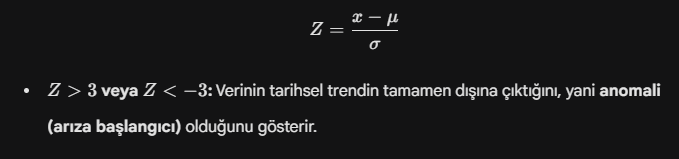

In [14]:
import time

# Basit bir önbellek sözlüğü
heavy_calculation_cache = {}

def calculate_risk_score(age: int, occupation_id: int, city_code: int):
    # Parametreleri tuple içinde paketleerek benzersiz bir anahtar üretiyoruz
    state_key = (age, occupation_id, city_code)
    
    if state_key in heavy_calculation_cache:
        return heavy_calculation_cache[state_key]
    
    # Eğer cache'de yoksa ağır hesaplamayı yap (Simüle ediliyor)
    time.sleep(2) 
    result = (age * occupation_id) / city_code
    
    # Sonucu cache'e kaydet
    heavy_calculation_cache[state_key] = result
    print(heavy_calculation_cache)
    return result

# İlk çağrı: 2 saniye sürer, hesaplar ve cache'e yazar
# score1 = calculate_risk_score(35, 102, 34)
# print(score1)

# İkinci çağrı: 0 saniye sürer, doğrudan hash tablosundan tuple key ile veriyi çeker
score2 = calculate_risk_score(35, 102, 34)
score2

{(35, 102, 34): 105.0}


105.0

## MQTT QOS => quality of service 0/1/2

In [ ]:
# QoS 0: At Most Once => Fire and Forget
# Publisher will send message and will not control if it is delivered or not.
# There is no PUBACK to approve that messeg reached or not to the destination
# Network traffic has lowest packet. Only messages will be send (Publish). One way just sending message.
# Risk, if that moment internet will gone, message will lost and will be resended


# Publisher =====> Publish(message) ======> Broker

# Why choose Qos 0 ====> data flows in a second, so if there is internet connection interrupted and cause to lost =>
# 3 seconds data, but from 4th second updated and display updated state. there is no necessary to resend lost datas =>
# again to occupy space in that band. 

In [ ]:
# QoS 1: At Least Once
# Mechanism wants to ensure that message delivered to broker. Publisher sends messages and waits (PUBACK) approved =>
# message from Broker.
# if approved message (PUBACK) will not come to the Publisher from Broker in defined timeframe, Publisher will send 
# message until getting approvement from Broker.
# Network traffic Two way. One way Publish packet sended, two PUBACK packet will return.
# Risk If Broker get message (Publish) but while sending approvement (PUBACK) VPN or internet interrupting, Publisher 
# will assume that message(Publish) didnt reached to Broker and will send that same message again. So this will cause
# duplicate (same message) message in receiver (Broker) side.

# 1Publisher ====> Publish(msg) =====> 2Broker ====> PUBACK(appr) ====> 1Publisher
# Why to choose Qos 1 There is no way to lost critical alarm. This alarm must be written to the db (timescaledb)
# Displaying Dublicate messages (repated message) are better and acceptable than messages lost and no messages there at all
# in this situation in app level possible to remove or filter same message, duplications with timestamps.

In [ ]:
# Qos 3: Exactly once
# Secure and heavy level of this protocol. there is no chance to be lost or duplication for data. To provide that there
# are 4 way handshake mechanism:
# PUBLISH ==> Publisher will send message with unique ID
# PUBREC (Publish Received) ==> Broker will register message and will send PUBREC "that message got, waiting for approve" 
# PUBREL (Publish Release) ==> Publisher "OK, complete the handshake" and let out msg from queue
# PUBCOM (Publish Complete) ==> Broker finishe the process and approve it

# Publisher ====> Publish ====> Broker ====> Pubrec ====> Publisher ====> Pubrel ====> Broker ====> Pubcom ====> Publisher
# In internet interruption sending Command to close valve two times can cause logical error in a system. Same for e-com
# to drop order two times from stock can cause financial lost. That's why process have to be done exactly once.add(element) 